Section 1: Basic Data Understanding

In [17]:
 #Step1:Import required libraries
import pandas as pd
import numpy as np

# Step 2:Load the dataset
df = pd.read_csv('Financial_EDA_data.csv')


In [18]:
# Step 3: Display dataset information
#Display dataset information
print("\nDataset info:")
print(df.info())



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2050 entries, 0 to 2049
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   TransactionDate    2050 non-null   object 
 1   AccountID          2050 non-null   object 
 2   TransactionAmount  1999 non-null   float64
 3   Merchant           2050 non-null   object 
 4   Category           1953 non-null   object 
 5   IsFraud            2050 non-null   int64  
 6   CustomerAge        2050 non-null   int64  
 7   CreditScore        2050 non-null   int64  
dtypes: float64(1), int64(3), object(4)
memory usage: 128.3+ KB
None


In [19]:
#Check data types of each column
print("\nData types:")
print(df.dtypes)


Data types:
TransactionDate       object
AccountID             object
TransactionAmount    float64
Merchant              object
Category              object
IsFraud                int64
CustomerAge            int64
CreditScore            int64
dtype: object


In [20]:
#  Summary statistics
print("\nSummary statistics:")
print(df.describe())


Summary statistics:
       TransactionAmount      IsFraud  CustomerAge  CreditScore
count        1999.000000  2050.000000  2050.000000  2050.000000
mean          117.696476     0.053171    53.602439   574.583415
std           291.560158     0.224429    20.345083   158.114374
min             0.018655     0.000000    18.000000   300.000000
25%            30.401436     0.000000    36.000000   442.000000
50%            74.149859     0.000000    54.000000   572.000000
75%           147.230622     0.000000    71.000000   709.750000
max          6849.350673     1.000000    89.000000   849.000000


Section 2: Missing Value Identification & Remediation

In [22]:
# Step 4: Check for missing values
print("\nMissing Values (True means missing):")
print(df.isnull())


Missing Values (True means missing):
      TransactionDate  AccountID  TransactionAmount  Merchant  Category  \
0               False      False              False     False     False   
1               False      False              False     False     False   
2               False      False              False     False     False   
3               False      False              False     False     False   
4               False      False              False     False     False   
...               ...        ...                ...       ...       ...   
2045            False      False              False     False     False   
2046            False      False              False     False     False   
2047            False      False              False     False     False   
2048            False      False              False     False     False   
2049            False      False              False     False     False   

      IsFraud  CustomerAge  CreditScore  
0       False      

In [7]:
# Step 5: Count missing values in each column
print("\nMissing Values Count:")
print(df.isnull().sum())


Missing Values Count:
TransactionDate       0
AccountID             0
TransactionAmount    51
Merchant              0
Category             97
IsFraud               0
CustomerAge           0
CreditScore           0
dtype: int64


In [8]:
#Step 6: Handle missing values
#Fill missing values using mean (for numeric columns)
df.fillna(df.mean(numeric_only=True), inplace=True)
# Verify missing values are handled
print("\nAfter Handling Missing Values:")
print(df.isnull().sum())



After Handling Missing Values:
TransactionDate       0
AccountID             0
TransactionAmount     0
Merchant              0
Category             97
IsFraud               0
CustomerAge           0
CreditScore           0
dtype: int64


Section 3: Outlier & Extreme Value Detection

In [9]:
# Step 7: Identify outliers using statistical summary
print("\nChecking for Outliers using describe():")
print(df.describe())


Checking for Outliers using describe():
       TransactionAmount      IsFraud  CustomerAge  CreditScore
count        2050.000000  2050.000000  2050.000000  2050.000000
mean          117.696476     0.053171    53.602439   574.583415
std           287.908800     0.224429    20.345083   158.114374
min             0.018655     0.000000    18.000000   300.000000
25%            31.691443     0.000000    36.000000   442.000000
50%            76.446025     0.000000    54.000000   572.000000
75%           144.532484     0.000000    71.000000   709.750000
max          6849.350673     1.000000    89.000000   849.000000


In [10]:
#Step 8: Handle outliers
# Replace outliers using median
for col in df.select_dtypes(include=np.number).columns:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    median_value = df[col].median()
    
    df[col] = np.where((df[col] < lower) | (df[col] > upper),
                       median_value,
                       df[col])

print("Dataset after replacing outliers with median:")
print(df)


Dataset after replacing outliers with median:
     TransactionDate  AccountID  TransactionAmount    Merchant   Category  \
0          4/13/2023  ACCT_1177          16.313264      Target       Food   
1          3/11/2024  ACCT_1406         178.178885     Walmart  Transport   
2          9/28/2023  ACCT_1427          16.961375      Target     Retail   
3          4/17/2023  ACCT_1293         152.504313  LocalStore  Utilities   
4          3/13/2023  ACCT_1339         132.643398     Unknown  Utilities   
...              ...        ...                ...         ...        ...   
2045       9/15/2024  ACCT_1139          32.700103        Uber       Food   
2046       5/26/2023  ACCT_1218         174.822714  LocalStore  Utilities   
2047      12/27/2024  ACCT_1236         192.300479     Walmart     Retail   
2048       9/15/2024  ACCT_1145          36.130839      Target       Food   
2049       12/4/2023  ACCT_1081         128.427758      Amazon  Transport   

      IsFraud  CustomerAge  C

In [11]:
# Step 9: Display cleaned dataset
print("\nCleaned Dataset:")
print(df)


Cleaned Dataset:
     TransactionDate  AccountID  TransactionAmount    Merchant   Category  \
0          4/13/2023  ACCT_1177          16.313264      Target       Food   
1          3/11/2024  ACCT_1406         178.178885     Walmart  Transport   
2          9/28/2023  ACCT_1427          16.961375      Target     Retail   
3          4/17/2023  ACCT_1293         152.504313  LocalStore  Utilities   
4          3/13/2023  ACCT_1339         132.643398     Unknown  Utilities   
...              ...        ...                ...         ...        ...   
2045       9/15/2024  ACCT_1139          32.700103        Uber       Food   
2046       5/26/2023  ACCT_1218         174.822714  LocalStore  Utilities   
2047      12/27/2024  ACCT_1236         192.300479     Walmart     Retail   
2048       9/15/2024  ACCT_1145          36.130839      Target       Food   
2049       12/4/2023  ACCT_1081         128.427758      Amazon  Transport   

      IsFraud  CustomerAge  CreditScore  
0         0.0  

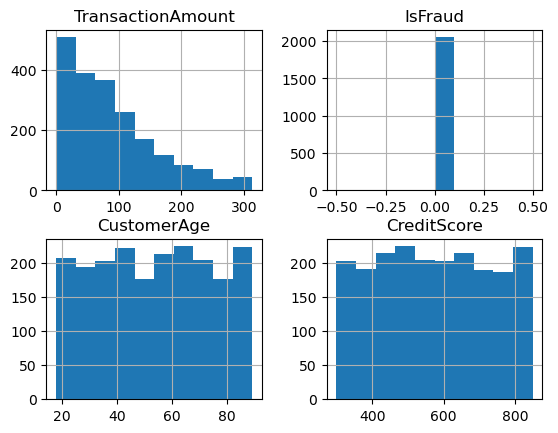

In [13]:
#Step 10:Plot the clean data
import matplotlib.pyplot as plt

# Plot histogram of cleaned data
df.hist()
plt.show()

In [14]:
print("\nEDA Completed Successfully")


EDA Completed Successfully
